In [50]:
%pip install torch_geometric

In [51]:
import numpy as np # type: ignore
import torch # type: ignore
import matplotlib.pyplot as plt # type: ignore
import networkx as nx # type: ignore

from torch_geometric.data import Data # type: ignore
from torch_geometric.utils import to_networkx, to_dense_adj # type: ignore

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch version:", torch.__version__)
print("PyTorch Geometric version:", torch.__version__)

PyTorch version: 2.10.0+cpu
PyTorch Geometric version: 2.10.0+cpu


In [52]:
def make_sbm_graph(n_nodes, block_sizes, p_intra, p_inter):
    """
    Generates a single snapshot of a stochastic block model

    Args:
        n_nodes (int): The total number of nodes in the graph (must equal sum of block_sizes)
        block_sizes (list of int): The number of nodes in each block
        e.g. [10, 10] for 2 communities of 10
        p_intra (float): The probability of an edge within a block (e.g. 0.8 for dense communities)
        p_inter (float): The probability of an edge between blocks (e.g. 0.1 for sparse inter-community connections)

    Returns:
        Data: A PyTorch Geometric Data object representing the graph
    """
    # sizes = how many nodes in each block
    # probs = probability of edges within and between blocks
    sizes = block_sizes
    probs = [
        [p_intra if i == j else p_inter for j in range(len(block_sizes))]
        for i in range(len(block_sizes))
    ]

    G = nx.stochastic_block_model(sizes, probs, seed=SEED)
    return G

In [53]:
def evolve_graph(G_prev, p_remove, p_add):
    """
    Evolves a graph with SEPARATE probabilities for adding
    and removing edges.

    This gives us control over the graph density over time.
    By setting p_add < p_remove (or tuning them to balance),
    we prevent the graph from drifting to full connectivity.

    The key intuition:
        - p_remove : probability an existing edge disappears
        - p_add    : probability a non-edge becomes an edge

    At stationarity (long-run equilibrium), the expected
    density satisfies:
        density ≈ p_add / (p_add + p_remove)

    So if p_add=0.05 and p_remove=0.15:
        density ≈ 0.05 / 0.20 = 0.25  →  ~25% of edges present

    Args:
        G_prev   : NetworkX graph at time t
        p_remove : probability of removing an existing edge
        p_add    : probability of adding a non-existing edge

    Returns:
        G_new : NetworkX graph at time t+1
    """
    G_new = G_prev.copy()
    nodes = list(G_prev.nodes())

    for i in nodes:
        for j in nodes:
            if i < j:  # Avoid double counting and self-loops
                if G_prev.has_edge(i, j):
                    # Existing edge: remove with probability p_remove
                    if np.random.rand() < p_remove:
                        G_new.remove_edge(i, j)
                else:
                    # Non-edge: add with probability p_add
                    if np.random.rand() < p_add:
                        G_new.add_edge(i, j)
    return G_new

In [54]:
# def generate_sequence(n_nodes, block_sizes, p_intra, p_inter, p_flip, T):
#     """
#     Generates a sequence of evolving graphs

#     Args:
#         n_nodes (int): Total number of nodes in the graph
#         block_sizes (list of int): Sizes of each community block
#         p_intra (float): Probability of edges within blocks
#         p_inter (float): Probability of edges between blocks
#         p_flip (float): Probability of flipping edges at each step
#         T (int): number of timesteps (length of sequence)

#     Returns:
#         list of networkx.Graph: A list of evolved graph snapshots [G_0, G_1, ..., G_{T-1}]
#     """
#     G0 = make_sbm_graph(n_nodes, block_sizes, p_intra, p_inter)
#     sequence = [G0]
#     for _ in range(T -1):
#         G_next = evolve_graph(sequence[-1], p_flip)
#         sequence.append(G_next)
#     return sequence

In [55]:
def graph_to_pyg(G, n_nodes):
    """
    Converts a NetworkX graph into a PyTorch Geometric Data object.

    In PyG, graphs are stored in COO (Coordinate) format:
        edge_index : shape [2, num_edges]
                     edge_index[0] = source nodes
                     edge_index[1] = destination nodes

    Since we have no natural node features here, we use the
    node degree as a simple 1D feature vector.
    Using degree as a feature is a common proxy — it gives
    the GNN something structural to work with.

    Args:
        G       : NetworkX graph
        n_nodes : total number of nodes (needed to handle isolated nodes)

    Returns:
        data : PyG Data object with fields:
               .x          → node features  [n_nodes, 1]
               .edge_index → edge list      [2, num_edges]
               .num_nodes  → n_nodes
    """
    #features: degree of each node (shape [n_nodes, 1])
    degrees = dict(G.degree())
    x = torch.tensor(
        [[degrees.get(i, 0)] for i in range(n_nodes)],
        dtype=torch.float
    )

    #edges: list of (source, target) pairs
    edges = list(G.edges())
    if len(edges) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        src = [u for u, v in edges] + [v for u, v in edges]  # undirected: add both directions
        dst = [v for u, v in edges] + [u for u, v in edges]
        edge_index = torch.tensor([src, dst], dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, num_nodes=n_nodes)
    return data


In [56]:
def generate_dataset(n_sequences, n_nodes, block_sizes,
                     p_intra, p_inter, p_remove, p_add, T):
    """
    Generates multiple independent evolving graph sequences.

    Each sequence starts from a freshly sampled SBM graph,
    then evolves for T steps. This gives us diversity in the
    training set — the model sees many different starting
    configurations, not just one trajectory.

    Args:
        n_sequences : how many independent sequences to generate
        n_nodes     : number of nodes (fixed)
        block_sizes : SBM community sizes
        p_intra     : intra-community edge probability (initial SBM)
        p_inter     : inter-community edge probability (initial SBM)
        p_remove    : probability of removing an edge per step
        p_add       : probability of adding an edge per step
        T           : timesteps per sequence

    Returns:
        all_sequences : list of sequences
                        shape: [n_sequences, T] of NetworkX graphs
        all_pairs     : list of (G_t, G_{t+1}) PyG pairs across
                        all sequences — ready for training
    """
    all_sequences = []
    all_pairs = []

    for seq_idx in range(n_sequences):
        G0 = make_sbm_graph(n_nodes, block_sizes, p_intra, p_inter)
        sequence = [G0]
        for t in range(T - 1):
            G_next = evolve_graph(sequence[-1], p_remove, p_add)
            sequence.append(G_next)

        all_sequences.append(sequence)

        pyg_sequence = [graph_to_pyg(G, n_nodes) for G in sequence]
        for t in range(T - 1):
            all_pairs.append((pyg_sequence[t], pyg_sequence[t + 1]))

    return all_sequences, all_pairs


In [57]:
N_NODES     = 20
BLOCK_SIZES = [10, 10]
P_INTRA     = 0.7
P_INTER     = 0.05
P_REMOVE    = 0.15    # existing edges removed with 15% chance
P_ADD       = 0.05    # non-edges added with 5% chance. Equilibrium density ≈ 0.05 / (0.05 + 0.15) = 0.25
T           = 20
N_SEQ       = 50      # 50 independent sequences → 50×19 = 950 training pairs

all_sequences, all_pairs = generate_dataset(
    N_SEQ, N_NODES, BLOCK_SIZES,
    P_INTRA, P_INTER, P_REMOVE, P_ADD, T
)

seq0 = all_sequences[0]
print("Edge counts in sequence 0:")
for t in [0, 5, 10, 15, 19]:
    print(f"  t={t:2d} → {seq0[t].number_of_edges()} edges")

print(f"\nTotal (input, target) training pairs: {len(all_pairs)}")

Edge counts in sequence 0:
  t= 0 → 71 edges
  t= 5 → 63 edges
  t=10 → 49 edges
  t=15 → 53 edges
  t=19 → 51 edges

Total (input, target) training pairs: 950


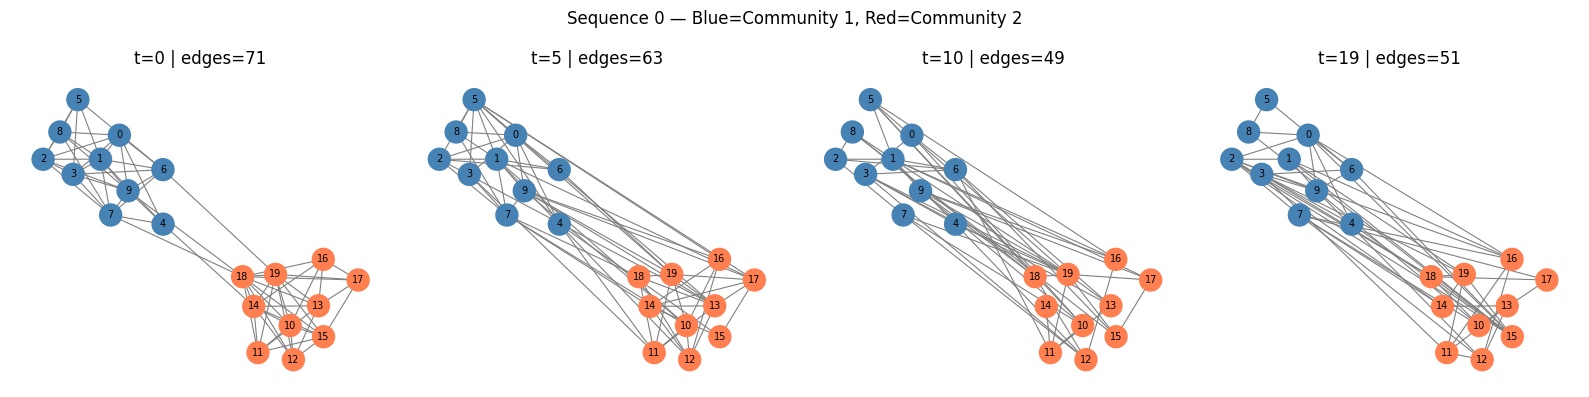

In [58]:
# Graph snapshots from sequence 0
pos = nx.spring_layout(seq0[0], seed=SEED)
timesteps_to_plot = [0, 5, 10, 19]
colors = ['steelblue'] * 10 + ['coral'] * 10  # colour the two communities

# Separate figure for graph snapshots
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, t in zip(axes, timesteps_to_plot):
    nx.draw(
        seq0[t], pos=pos, ax=ax,
        node_color=colors, node_size=250,
        edge_color='gray', width=0.8,
        with_labels=True, font_size=7
    )
    ax.set_title(f"t={t} | edges={seq0[t].number_of_edges()}")

plt.suptitle("Sequence 0 — Blue=Community 1, Red=Community 2", fontsize=12)
plt.tight_layout()
plt.show()

In [59]:
import torch.nn as nn # type: ignore
from torch_geometric.nn import GCNConv, global_mean_pool # type: ignore

class GCNEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, latent_dim):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.fc = nn.Linear(hidden_channels, latent_dim)
        self.relu = nn.ReLU()

    def forward(self, x, edge_index, batch):
        h = self.relu(self.conv1(x, edge_index))
        h = self.relu(self.conv2(h, edge_index))
        h = global_mean_pool(h, batch)  # [batch_size, hidden_channels]
        z = self.fc(h)  # [batch_size, latent_dim]
        return z

In [60]:
class MLPDecoder(nn.Module):
    def __init__(self, latent_dim, n_nodes, hidden_dim):
        super().__init__()
        self.n_nodes = n_nodes
        self.n_edges = n_nodes * (n_nodes - 1) // 2  # undirected, no self-loops
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, self.n_edges),
            nn.Sigmoid()
        )

    def forward(self, z):
        edge_probs = self.net(z)  # [batch_size, n_edges]
        B = z.size(0)
        N = self.n_nodes
        adj = torch.zeros((B, N, N), device=z.device)
        idx = torch.triu_indices(N, N, offset=1)
        adj[:, idx[0], idx[1]] = edge_probs
        adj[:, idx[1], idx[0]] = edge_probs  # symmetric
        return adj

In [61]:
from torch_geometric.data import Batch # type: ignore

IN_CHANNELS = 1
HIDDEN_CHANNELS = 32
LATENT_DIM = 16

encoder = GCNEncoder(IN_CHANNELS, HIDDEN_CHANNELS, LATENT_DIM)
decoder = MLPDecoder(LATENT_DIM, N_NODES, HIDDEN_CHANNELS)

sample_inputs = [all_pairs[i][0] for i in range(4)]
batch = Batch.from_data_list(sample_inputs)

print("=== Batch info ===")
print(f"  x shape         : {batch.x.shape}")        # [N_total, 1]
print(f"  edge_index shape: {batch.edge_index.shape}")
print(f"  batch vector    : {batch.batch.shape}")    # [N_total]

z = encoder(batch.x, batch.edge_index, batch.batch)
print(f"\n=== Encoder output ===")
print(f"  z shape: {z.shape}")   # should be [4, LATENT_DIM]

adj_pred = decoder(z)
print(f"\n=== Decoder output ===")
print(f"  adj_pred shape : {adj_pred.shape}")   # should be [4, 20, 20]
print(f"  value range    : [{adj_pred.min():.3f}, {adj_pred.max():.3f}]")
print(f"  is symmetric   : {torch.allclose(adj_pred, adj_pred.transpose(1,2))}")

=== Batch info ===
  x shape         : torch.Size([80, 1])
  edge_index shape: torch.Size([2, 514])
  batch vector    : torch.Size([80])

=== Encoder output ===
  z shape: torch.Size([4, 16])

=== Decoder output ===
  adj_pred shape : torch.Size([4, 20, 20])
  value range    : [0.000, 0.641]
  is symmetric   : True


In [62]:
class MLPTransition(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )

    def forward(self, z):
        return self.net(z)

In [63]:
class KoopmanTransition(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.K = nn.Parameter(
            torch.randn(latent_dim, latent_dim) * 0.1
        )

    def forward(self, z):
        return z @ self.K.T

    def spectral_penalty(self):
        eigenvalues = torch.linalg.eigvals(self.K)
        magnitudes = torch.abs(eigenvalues)
        penalty = torch.relu(magnitudes - 1.0).mean()
        return penalty

In [64]:
mlp_transition      = MLPTransition(LATENT_DIM, HIDDEN_CHANNELS)
koopman_transition  = KoopmanTransition(LATENT_DIM)

# Use the z we already computed in Cell 7 (shape: [4, 16])
z_next_mlp     = mlp_transition(z)
z_next_koopman = koopman_transition(z)

print("=== MLP Transition ===")
print(f"  Input  z shape : {z.shape}")
print(f"  Output z shape : {z_next_mlp.shape}")

print("\n=== Koopman Transition ===")
print(f"  Input  z shape : {z.shape}")
print(f"  Output z shape : {z_next_koopman.shape}")
print(f"  K matrix shape : {koopman_transition.K.shape}")

# Check eigenvalue magnitudes before training
eigvals     = torch.linalg.eigvals(koopman_transition.K)
magnitudes  = torch.abs(eigvals)
print(f"\n  Eigenvalue magnitudes (before training):")
print(f"    min : {magnitudes.min().item():.4f}")
print(f"    max : {magnitudes.max():.4f}")
print(f"    mean: {magnitudes.mean():.4f}")
print(f"\n  Spectral penalty (before training): "
      f"{koopman_transition.spectral_penalty().item():.4f}")

# Count parameters in each model
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n=== Parameter count ===")
print(f"  Encoder           : {count_params(encoder):,}")
print(f"  Decoder           : {count_params(decoder):,}")
print(f"  MLP Transition    : {count_params(mlp_transition):,}")
print(f"  Koopman Transition: {count_params(koopman_transition):,}")

=== MLP Transition ===
  Input  z shape : torch.Size([4, 16])
  Output z shape : torch.Size([4, 16])

=== Koopman Transition ===
  Input  z shape : torch.Size([4, 16])
  Output z shape : torch.Size([4, 16])
  K matrix shape : torch.Size([16, 16])

  Eigenvalue magnitudes (before training):
    min : 0.0597
    max : 0.3690
    mean: 0.2667

  Spectral penalty (before training): 0.0000

=== Parameter count ===
  Encoder           : 1,648
  Decoder           : 6,814
  MLP Transition    : 2,128
  Koopman Transition: 256


In [65]:
from torch_geometric.utils import to_dense_adj # type: ignore

def compute_loss(encoder, transition, decoder, batch_input, batch_target, n_nodes, spectral_weight=0.1, pos_weight_val=None):
    """
    Computes the loss for a single (input, target) pair.

    Args:
        encoder         : GCNEncoder instance
        transition       : MLPTransition or KoopmanTransition instance
        decoder          : MLPDecoder instance
        batch_input      : PyG Batch object for G_t
        batch_target     : PyG Batch object for G_{t+1}
        n_nodes          : number of nodes in the graph (for adjacency)
        spectral_weight  : weight for the spectral penalty (Koopman only)

    Returns:
        loss: torch.Tensor
    """
    z_t = encoder(batch_input.x, batch_input.edge_index, batch_input.batch)
    z_t1_pred = transition(z_t)
    adj_pred = decoder(z_t1_pred)

    adj_true = to_dense_adj(
        batch_target.edge_index,
        batch=batch_target.batch,
        max_num_nodes=n_nodes
    )

    idx = torch.triu_indices(n_nodes, n_nodes, offset=1)

    pred_flat = adj_pred[:, idx[0], idx[1]]
    true_flat = adj_true[:, idx[0], idx[1]]

    if pos_weight_val is None:
        n_pos = true_flat.sum().clamp(min=1)
        n_neg = (1 - true_flat).sum().clamp(min=1)
        pos_weight_val = (n_neg / n_pos).detach()

    pos_weight = torch.tensor([pos_weight_val])

    pred_logits = torch.log(
        pred_flat.clamp(1e-6, 1 - 1e-6) /
        (1 - pred_flat).clamp(1e-6, 1 - 1e-6)
    )

    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    loss_recon = loss_fn(pred_logits, true_flat)

    if hasattr(transition, 'spectral_penalty'):
        loss_spectral = transition.spectral_penalty()
        total_loss = loss_recon + spectral_weight * loss_spectral
    else:
        total_loss = loss_recon
    return total_loss, loss_recon

In [66]:
from torch.utils.data import DataLoader # type: ignore
from torch_geometric.data import Batch # type: ignore
import random

def train_model(transition_model, n_epochs = 100, batch_size = 32,
                lr = 1e-3, spectral_weight = 0.01, seed = 42):
    torch.manual_seed(seed)
    random.seed(seed)

    enc = GCNEncoder(IN_CHANNELS, HIDDEN_CHANNELS, LATENT_DIM)
    dec = MLPDecoder(LATENT_DIM, N_NODES, HIDDEN_CHANNELS)

    trans = transition_model

    optimizer = torch.optim.Adam(
        list(enc.parameters()) +
        list(dec.parameters()) +
        list(trans.parameters()),
        lr=lr
    )

    loss_history = []
    pairs_shuffled = all_pairs.copy()

    for epoch in range(n_epochs):
        random.shuffle(pairs_shuffled)
        epoch_losses = []

        for start in range(0, len(pairs_shuffled), batch_size):
            batch_pairs = pairs_shuffled[start:start + batch_size]
            if len(batch_pairs) == 0:
                continue

            batch_input = Batch.from_data_list([p[0] for p in batch_pairs])
            batch_target = Batch.from_data_list([p[1] for p in batch_pairs])

            optimizer.zero_grad()
            loss, recon_loss = compute_loss(
                enc, trans, dec, batch_input, batch_target, N_NODES,
                spectral_weight=spectral_weight
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                list(enc.parameters()) +
                list(dec.parameters()) +
                list(trans.parameters()),
                max_norm=1.0
            )

            optimizer.step()
            epoch_losses.append(recon_loss.item())
        avg_loss = sum(epoch_losses) / len(epoch_losses)
        loss_history.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} | "
                  f"Recon Loss: {avg_loss:.4f}")

    return enc, dec, trans, loss_history

In [67]:
# ----- Train MLP model -----
print("=" * 45)
print("Training MLP Transition Model")
print("=" * 45)
mlp_trans = MLPTransition(LATENT_DIM, HIDDEN_CHANNELS)
enc_mlp, dec_mlp, mlp_trans, losses_mlp = train_model(mlp_trans)

# ----- Train Koopman model -----
print("\n" + "=" * 45)
print("Training Koopman Transition Model")
print("=" * 45)
koop_trans = KoopmanTransition(LATENT_DIM)
enc_koop, dec_koop, koop_trans, losses_koop = train_model(koop_trans)

Training MLP Transition Model
Epoch  10/100 | Recon Loss: 0.9409
Epoch  20/100 | Recon Loss: 0.9203
Epoch  30/100 | Recon Loss: 0.9181
Epoch  40/100 | Recon Loss: 0.9157
Epoch  50/100 | Recon Loss: 0.9157
Epoch  60/100 | Recon Loss: 0.9139
Epoch  70/100 | Recon Loss: 0.9149
Epoch  80/100 | Recon Loss: 0.9130
Epoch  90/100 | Recon Loss: 0.9128
Epoch 100/100 | Recon Loss: 0.9119

Training Koopman Transition Model
Epoch  10/100 | Recon Loss: 0.9421
Epoch  20/100 | Recon Loss: 0.9202
Epoch  30/100 | Recon Loss: 0.9187
Epoch  40/100 | Recon Loss: 0.9160
Epoch  50/100 | Recon Loss: 0.9160
Epoch  60/100 | Recon Loss: 0.9140
Epoch  70/100 | Recon Loss: 0.9149
Epoch  80/100 | Recon Loss: 0.9131
Epoch  90/100 | Recon Loss: 0.9131
Epoch 100/100 | Recon Loss: 0.9126


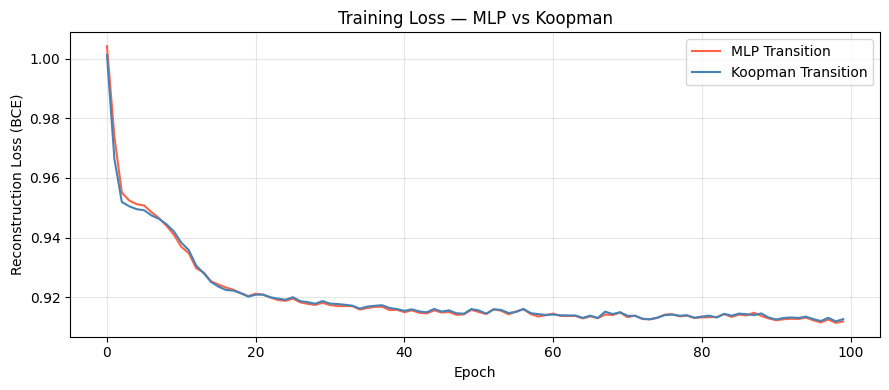

Final loss — MLP    : 0.9119
Final loss — Koopman: 0.9126


In [68]:
plt.figure(figsize=(9, 4))
plt.plot(losses_mlp,   label='MLP Transition',     color='tomato')
plt.plot(losses_koop,  label='Koopman Transition',  color='steelblue')
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss (BCE)")
plt.title("Training Loss — MLP vs Koopman")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final loss — MLP    : {losses_mlp[-1]:.4f}")
print(f"Final loss — Koopman: {losses_koop[-1]:.4f}")

In [69]:
sample_in, sample_tgt = all_pairs[0]

batch_in  = Batch.from_data_list([sample_in])
batch_tgt = Batch.from_data_list([sample_tgt])

# Get prediction from Koopman model
enc_koop.eval()
dec_koop.eval()
koop_trans.eval()

with torch.no_grad():
    z       = enc_koop(batch_in.x, batch_in.edge_index, batch_in.batch)
    z_next  = koop_trans(z)
    adj_pred = dec_koop(z_next)                       # [1, 20, 20]

# Ground truth adjacency
adj_true = to_dense_adj(
    batch_tgt.edge_index,
    batch=batch_tgt.batch,
    max_num_nodes=N_NODES
)                                                      # [1, 20, 20]

# Threshold at 0.5 → binary prediction
adj_binary = (adj_pred > 0.5).float()

idx       = torch.triu_indices(N_NODES, N_NODES, offset=1)
pred_flat = adj_binary[0, idx[0], idx[1]]
true_flat = adj_true[0,  idx[0], idx[1]]

n_true_edges  = true_flat.sum().item()
n_pred_edges  = pred_flat.sum().item()
n_correct     = (pred_flat == true_flat).sum().item()
accuracy      = n_correct / len(true_flat) * 100

print(f"True edges predicted : {n_true_edges:.0f}")
print(f"Predicted edges      : {n_pred_edges:.0f}")
print(f"Edge-level accuracy  : {accuracy:.1f}%")
print(f"\n(Baseline — predict no edges: "
      f"{(1 - true_flat).sum().item() / len(true_flat) * 100:.1f}%)")

True edges predicted : 62
Predicted edges      : 71
Edge-level accuracy  : 88.9%

(Baseline — predict no edges: 67.4%)


In [70]:
def multi_step_rollout(encoder, transition, decoder, sequence, n_nodes, n_steps):
    encoder.eval()
    transition.eval()
    decoder.eval()

    accuracies = []
    f1_scores   = []

    with torch.no_grad():
        g0 = Batch.from_data_list([sequence[0]])
        z = encoder(g0.x, g0.edge_index, g0.batch)

        for step in range(1, n_steps + 1):
            z = transition(z)

            adj_pred = decoder(z)
            adj_binary = (adj_pred > 0.5).float()

            g_true = Batch.from_data_list([sequence[step]])
            adj_true = to_dense_adj(
                g_true.edge_index,
                batch=g_true.batch,
                max_num_nodes=n_nodes
            )

            idx = torch.triu_indices(n_nodes, n_nodes, offset=1)
            pred_flat = adj_binary[0, idx[0], idx[1]]
            true_flat = adj_true[0,  idx[0], idx[1]]

            accuracy = (pred_flat == true_flat).float().mean().item()
            accuracies.append(accuracy)

            tp = (pred_flat * true_flat).sum().item()
            fp = (pred_flat * (1 - true_flat)).sum().item()
            fn = ((1 - pred_flat) * true_flat).sum().item()
            precision = tp / (tp + fp + 1e-8)
            recall = tp / (tp + fn + 1e-8)
            f1 = 2 * precision * recall / (precision + recall + 1e-8)
            f1_scores.append(f1)
    return accuracies, f1_scores

In [71]:
EVAL_SEQS  = all_sequences[-10:]   # last 10 sequences
N_STEPS    = 15                    # roll out 15 steps

# Convert NetworkX sequences to PyG
def seq_to_pyg(sequence, n_nodes):
    return [graph_to_pyg(G, n_nodes) for G in sequence]

mlp_accs_all   = []
mlp_f1s_all    = []
koop_accs_all  = []
koop_f1s_all   = []

for seq in EVAL_SEQS:
    pyg_seq = seq_to_pyg(seq, N_NODES)

    accs, f1s = multi_step_rollout(
        enc_mlp, mlp_trans, dec_mlp, pyg_seq, N_NODES, N_STEPS
    )
    mlp_accs_all.append(accs)
    mlp_f1s_all.append(f1s)

    accs, f1s = multi_step_rollout(
        enc_koop, koop_trans, dec_koop, pyg_seq, N_NODES, N_STEPS
    )
    koop_accs_all.append(accs)
    koop_f1s_all.append(f1s)

# Average across sequences
import numpy as np # type: ignore
mlp_accs_mean   = np.mean(mlp_accs_all,  axis=0)
mlp_f1s_mean    = np.mean(mlp_f1s_all,   axis=0)
koop_accs_mean  = np.mean(koop_accs_all, axis=0)
koop_f1s_mean   = np.mean(koop_f1s_all,  axis=0)

steps = list(range(1, N_STEPS + 1))

print(f"{'Step':<6} {'MLP Acc':>10} {'Koop Acc':>10} "
      f"{'MLP F1':>10} {'Koop F1':>10}")
print("-" * 50)
for i, s in enumerate(steps):
    print(f"{s:<6} {mlp_accs_mean[i]:>10.3f} "
          f"{koop_accs_mean[i]:>10.3f} "
          f"{mlp_f1s_mean[i]:>10.3f} "
          f"{koop_f1s_mean[i]:>10.3f}")

Step      MLP Acc   Koop Acc     MLP F1    Koop F1
--------------------------------------------------
1           0.913      0.913      0.878      0.878
2           0.702      0.571      0.480      0.377
3           0.577      0.667      0.326      0.322
4           0.556      0.701      0.299      0.459
5           0.558      0.668      0.314      0.403
6           0.564      0.653      0.331      0.359
7           0.569      0.651      0.345      0.336
8           0.561      0.663      0.319      0.330
9           0.566      0.660      0.327      0.322
10          0.558      0.657      0.321      0.325
11          0.549      0.651      0.312      0.321
12          0.549      0.651      0.301      0.307
13          0.561      0.657      0.326      0.326
14          0.558      0.652      0.329      0.326
15          0.554      0.649      0.331      0.332


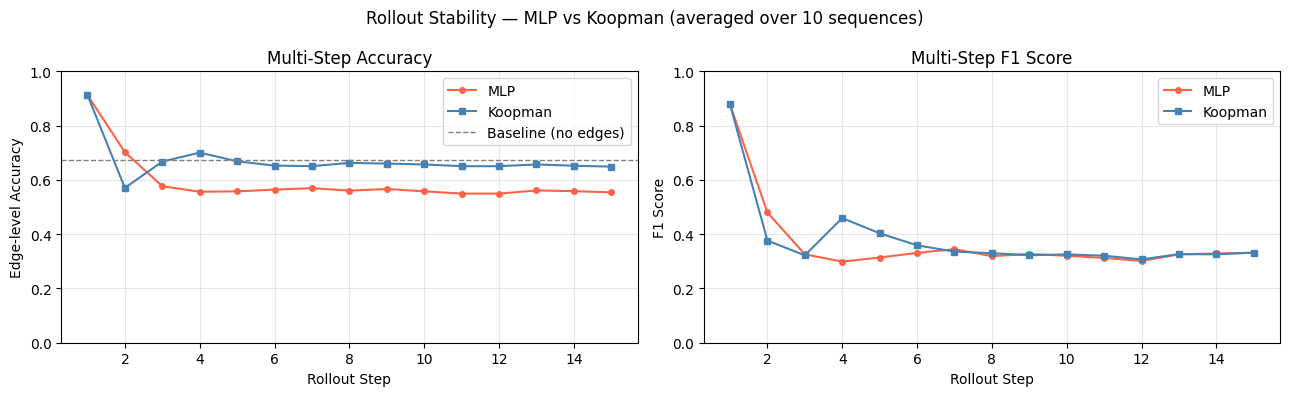


=== Summary (averaged over 10 eval sequences) ===
                  MLP   Koopman
Step-1  Acc:    0.913     0.913
Step-5  Acc:    0.558     0.668
Step-15 Acc:    0.554     0.649
Step-1  F1 :    0.878     0.878
Step-5  F1 :    0.314     0.403
Step-15 F1 :    0.331     0.332


In [72]:
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot 1: Edge-level accuracy over steps
axes[0].plot(steps, mlp_accs_mean,
             label='MLP',     color='tomato',    marker='o', markersize=4)
axes[0].plot(steps, koop_accs_mean,
             label='Koopman', color='steelblue', marker='s', markersize=4)
axes[0].axhline(y=0.674, color='gray', linestyle='--',
                linewidth=1, label='Baseline (no edges)')
axes[0].set_xlabel("Rollout Step")
axes[0].set_ylabel("Edge-level Accuracy")
axes[0].set_title("Multi-Step Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1)

# Plot 2: F1 score over steps
axes[1].plot(steps, mlp_f1s_mean,
             label='MLP',     color='tomato',    marker='o', markersize=4)
axes[1].plot(steps, koop_f1s_mean,
             label='Koopman', color='steelblue', marker='s', markersize=4)
axes[1].set_xlabel("Rollout Step")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Multi-Step F1 Score")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1)

plt.suptitle("Rollout Stability — MLP vs Koopman (averaged over 10 sequences)",
             fontsize=12)
plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== Summary (averaged over 10 eval sequences) ===")
print(f"             {'MLP':>8}  {'Koopman':>8}")
print(f"Step-1  Acc: {mlp_accs_mean[0]:>8.3f}  {koop_accs_mean[0]:>8.3f}")
print(f"Step-5  Acc: {mlp_accs_mean[4]:>8.3f}  {koop_accs_mean[4]:>8.3f}")
print(f"Step-15 Acc: {mlp_accs_mean[14]:>8.3f}  {koop_accs_mean[14]:>8.3f}")
print(f"Step-1  F1 : {mlp_f1s_mean[0]:>8.3f}  {koop_f1s_mean[0]:>8.3f}")
print(f"Step-5  F1 : {mlp_f1s_mean[4]:>8.3f}  {koop_f1s_mean[4]:>8.3f}")
print(f"Step-15 F1 : {mlp_f1s_mean[14]:>8.3f}  {koop_f1s_mean[14]:>8.3f}")